**NOTE** `phimats` environment should be used as kernel

In [ ]:
import numpy as np

from PreProcessing import PhysicsConfig, MeshConfig, PreProcessing as PP

from MeshManager import MeshManager

from BoundaryConditions import *

from PostProcessing import WriteXDMF

%load_ext autoreload
%autoreload 2

### Simulation data

In [9]:
SimulName = "SRB_30MPa"
# Element sets
nElementSets = 1
# Number of steps to achieve the load
nSteps = 400

### Read mesh file

In [ ]:
# Element name
elementName = "quad"  		# meshio compatible element name
mesh = MeshManager("../SmoothAxi.msh", elementName)
mesh.WriteMesh("../SmoothAxi")

In [11]:
# Create the config object
meshConfig = MeshConfig(
    nTotNodes=mesh.get_nTotNodes(),
    nTotElements=mesh.get_nTotElements(),
    nDim=mesh.get_nDim(),
    materialNames=mesh.getMaterialNames(),
)

### Apply mechanics boundary conditions
**NOTE** This is the total load to be achieved in `nSteps`.

In [ ]:
dl = 30e-3*0.28  # [m]

In [13]:
# Dirichlet BCs list
presBCs = []

# Top pull
presBCs.extend(AssignDirichletBC(mesh.getNodesByGroup("Top"), dof=1, value=dl))

# Bottom fix
presBCs.extend(AssignDirichletBC(mesh.getNodesByGroup("Bottom"), dof=1, value=0.0))

# Symmetry
presBCs.extend(AssignDirichletBC(mesh.getNodesByGroup("Symmetry_Axis"), dof=0, value=0.0))

# Bottom left corner pin (Fixed in X)
presBCs.extend(AssignDirichletBC(mesh.getNodesByGroup("Fix"), dof=0, value=0.0))

# Write external 
WriteBCVTK(SimulName, mesh, presBCs, dofNames=['ux', 'uy'])

BC visualization written to SRB_30MPa_BC.vtu


### Apply diffusion boundary conditions

In [14]:
cL = 4.4e-3 # wppm
rho_steel = 7850 # kg/m3
MH  = 1.008e3 # kg/mol atomic molar mass

# print(cL*rho_steel/MH) # to mol/m3

PH2 = 30e6  # Pa
S_sieverts = 6.2e-6 # mol/(m3.Pa^0.5)

cL = S_sieverts*np.sqrt(PH2)

In [15]:
# Dirichlet BCs list
conBCs = []
exitNods = []

# Surface con
conBCs.extend(AssignDirichletBC(mesh.getNodesByGroup("Surface"), dof=0, value=cL))

# Write external 
WriteBCVTK(SimulName, mesh, conBCs, dofNames=['con'])

BC visualization written to SRB_30MPa_BC.vtu


In [16]:
conBCs = [[row[0], row[-1]] for row in conBCs]

### Mechanical material data

In [17]:

# Analysis type
AnalysisType = "AxiSymmetricPFF"
# Isotropy
Isotropy = "Isotropic"
# Young's modulus
Emod = 210e9
# Poisson's ratio
nu = 0.3

# Plasticity type
Plasticity = "IsoHard"
HardeningLaw = "Voce"
sig_y0 = 533e6    # Pa
sig_sat = 685e6
H0 = 9000e6

rho_0 = 1e11  # Initial dislocation density (m⁻²)
M = 3 		  # Taylor factor
alpha = 0.3   # Dislocation interaction constant
b = 2.5e-10   # Burgers vector (m)
G = Emod/(2*(1+nu)) # Shear modulus
k1 = 2*(G/(200*G*alpha*b))  # Multiplication coefficient
k2 = 10  # Recovery coefficient

MechMaterial = {
	"SmoothAxi" : {
		"Elastic" : {
			"AnalysisType" : AnalysisType,
			"Isotropy" 	 : Isotropy,
			"Emod" 		 : Emod,
			"nu"   		 : nu,
		},
       	"Plastic" : {
			"Plasticity"   : Plasticity,
			"HardeningLaw" : HardeningLaw,
			"sig_y0"       : sig_y0,
			"sig_sat"      : sig_sat,
			"H0"           : H0,
			"rho_0"        : rho_0,
			"M"            : M,
			"b"            : b,
			"alpha"        : alpha,
			"k1"           : k1,
   			"k2"           : k2,
		},
	},
}

### Diffusion material data

In [18]:
# Trapping --------------

Erho = 20000  # Hydroge dislocation enthalpy (positive) [J/mol]

Vm = 7.09e-6  # Molar volume of Fe [m³/mol]
Vrho = 2*Vm   # Molar volume around dislocation  [m³/mol]
Vh = 2e-6     # Partial molar volume of hydrogen in Fe [m³]
N = 6          
R = 8.31      # Universal gas constant [J/(molK)]
T = 300       # Temperature [K]

theta_b = cL*Vm/N
print(theta_b)

Krho   = np.exp(Erho/(R*T))
theta_rho = theta_b*Krho 

Vrho = 2*Vm
c_rho = theta_rho/Vrho
print("c_rho", c_rho)
Z_rho = c_rho/cL
print("Z_rho", Z_rho)
zeta_rho = R*T*np.log(Z_rho)*0
print("zeta_rho", zeta_rho)

4.012798030468682e-08
c_rho 8.62744973832497
Z_rho 254.05638900121656
zeta_rho 0.0


In [19]:
# Diffusivity --------------

dt = 14   # Time increment [s]
s = 1      # Trapping capacity 
m = 0      # Dislocation diffusivity ratio

D0x = 8.45e-8; DQx = 15000  # Diffusivity m^2/s

DL = D0x*np.exp(-DQx/(R*T))

Zd = 0.01

print(DL)

2.0595540015833507e-10


In [20]:
DiffMaterial = {
    "SmoothAxi" : {
		"D0x" : D0x,
		"D0y" : D0x,
		"DQx" : DQx,
		"DQy" : DQx,
		"m"   : m,
		"s"   : s,
		"Vh"  : Vh,
		"zeta_rho"   : zeta_rho,
		"Zd"  : Zd,
    }
}

DiffMaterial

{'SmoothAxi': {'D0x': 8.45e-08,
  'D0y': 8.45e-08,
  'DQx': 15000,
  'DQy': 15000,
  'm': 0,
  's': 1,
  'Vh': 2e-06,
  'zeta_rho': np.float64(0.0),
  'Zd': 0.01}}

### PFF material data

C_crit:  3.395879856


Text(0, 0.5, '$\\tilde{w}_\\mathrm{c}(\\bar{c}$) (J/m³)')

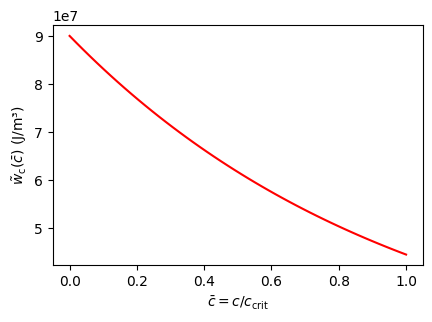

In [21]:
import matplotlib.pyplot as plt

wc0 = 90e6           # Critical work density [J/m³]
wc_min = wc0*0.2

c_hat = np.linspace(0,1)
c_DTB = cL*3
c_crit = 3.395879856

print("C_crit: ", c_crit)

beta = 1
wc1 = wc_min + (wc0 - wc_min) * np.exp(-beta * c_hat)

fig, ax = plt.subplots(figsize=(2*56.25/25.4, 1.5*56.25/25.4), dpi=100, tight_layout=True)

ax.plot(c_hat, wc1, color="r") 

ax.set_xlabel("$\\bar{c} =  c/c_\\mathrm{crit}$")
ax.set_ylabel("$\\tilde{w}_\\mathrm{c}(\\bar{c}$) (J/m³)")

In [22]:
const_ell = 3e-5      # Length-scale regularization parameter [m]
Gc = 2*const_ell*wc0  # Fracture toughness [J/m²]

PFFMaterial = {
	"SmoothAxi" : {
		"ChemoMech" : {
			"const_ell" : const_ell,
			"wc" 	    : wc0,
   			"wc_min" 	: wc_min, 
   			"beta" 	    : beta,
      		"c_DTB"     : c_DTB,
      		"c_crit" 	: c_crit,
		}
    }
}

print("l: ", const_ell, " m")
print("Gc: ", Gc, " J/m²")
print("w_c0: ", wc0, " J/m³")
print("w_cmin: ", wc_min, " J/m³")

l:  3e-05  m
Gc:  5400.0  J/m²
w_c0:  90000000.0  J/m³
w_cmin:  18000000.0  J/m³


In [23]:
np.exp(zeta_rho*0.98/(R*T))

np.float64(1.0)

In [24]:
np.exp(zeta_rho*0.98/(R*T))*cL

np.float64(0.0339587985653203)

### Initialize simulation object

### Mechanical

In [25]:
# Create the config object
mechPhysConfig = PhysicsConfig(
    SimulName = SimulName,
    PhysicsType = "Mechanical",
    PhysicsCategory = "Plastic",
    nSteps    = nSteps,
    presBCs=presBCs
)

In [26]:
MechNotch = PP(mechPhysConfig, meshConfig, MechMaterial)


PHIMATS: SRB_30MPa | Mechanical (Plastic)
  Nodes/Elems : 30405 / 29996
  Total DOFs  : 60810
  BCs Count   : 320



In [27]:
MechNotch.WriteInputFile()

  Input file initialized: SRB_30MPa.mech.in.hdf5


### Diffusion

In [28]:
# Create the config object
diffPhysConfig = PhysicsConfig(
    SimulName = SimulName,
    PhysicsType = "Transport",
    PhysicsCategory = "MechTrappingPFF",
    nSteps    = nSteps,
    dt = dt,
    conB=cL,
    presBCs=conBCs,
)

In [29]:
DiffNotch = PP(diffPhysConfig, meshConfig, DiffMaterial)


PHIMATS: SRB_30MPa | Transport (MechTrappingPFF)
  Nodes/Elems : 30405 / 29996
  Total DOFs  : 30405
  BCs Count   : 501



In [30]:
DiffNotch.WriteInputFile()

  Input file initialized: SRB_30MPa.diff.in.hdf5


#### PFF

In [31]:
# Create the config object
pffPhysConfig = PhysicsConfig(
    SimulName = SimulName,
    PhysicsType = "PFF",
    PhysicsCategory = list(PFFMaterial["SmoothAxi"].keys())[0],
    nSteps    = nSteps,
)

In [32]:
PFFNotch = PP(pffPhysConfig, meshConfig, PFFMaterial)


PHIMATS: SRB_30MPa | PFF (ChemoMech)
  Nodes/Elems : 30405 / 29996
  Total DOFs  : 30405
  BCs Count   : 0



In [33]:
PFFNotch.WriteInputFile()

  Input file initialized: SRB_30MPa.pff.in.hdf5


### Write output files

In [34]:
OVERWRITE = True

In [37]:
MechNotch.WriteOutputFile(overwrite=OVERWRITE)
DiffNotch.WriteOutputFile(OVERWRITE=True, AVCON=True, FLUX=True)
PFFNotch.WriteOutputFile(overwrite=OVERWRITE)

  Output file initialized: SRB_30MPa.mech.out.hdf5
  Output file initialized: SRB_30MPa.diff.out.hdf5
  Output file initialized: SRB_30MPa.pff.out.hdf5


The four components of `quadAxi` are:

1. **Radial Component ($r$):** Index `0`.
2. **Axial Component ($z$):** Index `1`.
3. **Hoop Component ($\theta$):** Acts in the circumferential direction. This is the "out-of-plane" normal stress/strain that arises due to the change in radius ($u_r/r$). This is index `2`.
4. **Shear Component ($rz$):** Represents the shear in the  plane. In your code, this is index `3`.

In [36]:

WriteXDMF(SimulName,       # Base simulation name
          "../SmoothAxi",  # Mesh file name
          "quadAxi",       # Element name
          nSteps+1,        # Number of steps 
          components=["mech", "pff", "diff"],
    nDim=2,
    mechModel="Plastic", # Adds strain_p, stress_eq, etc.
    FLUX=True)

**PETSc command line options**

```
./SRB_Boundary -snes_linesearch_type bt -snes_linesearch_damping 0.8 -snes_linesearch_monitor -snes_linesearch_max_it 50 -snes_max_it 100
```